# 05.3 - Logistic Regression (from scratch)

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

Logistic regression predicts the probability that a sample belongs to a class. We implement it **from scratch** in NumPy using the sigmoid function and log loss, then compare to scikit-learn.

## 2. Why Does This Matter?

Logistic regression is the go-to baseline for binary classification. Understanding the sigmoid, log loss, and gradient descent is essential for all classification models.

## 3. Prerequisites

- Phase 02 (Math), Phase 03 (Statistics), Unit 05.2

## 4. Learning Objectives

By the end of this unit, you should be able to:
- Write the sigmoid function and log loss
- Implement logistic regression from scratch
- Evaluate with accuracy, precision, recall, F1, ROC-AUC

## 5. Mental Model

z = w0 + w1*x1 + ... + wn*xn

p = sigmoid(z) = 1 / (1 + exp(-z))

Log loss: -(1/m) * sum(y*log(p) + (1-y)*log(1-p))

Gradient descent updates weights to minimize log loss.


## 6. Generate Synthetic Data

Create two-class data with a linear decision boundary.


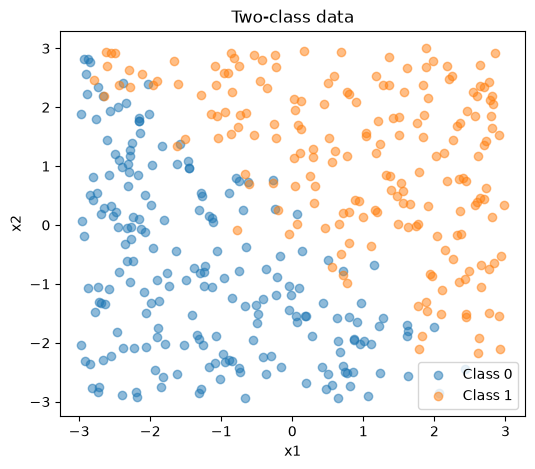

Class balance: 0.48


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

np.random.seed(42)
n = 400
X = np.random.uniform(-3, 3, (n, 2))
# Linear boundary: y=1 if x1 + x2 > 0
logit = X[:, 0] + X[:, 1] + np.random.normal(0, 0.5, n)
y = (logit > 0).astype(int)

plt.figure(figsize=(6, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], alpha=0.5, label="Class 0")
plt.scatter(X[y==1, 0], X[y==1, 1], alpha=0.5, label="Class 1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Two-class data")
plt.legend()
plt.show()
print(f"Class balance: {y.mean():.2f}")


## 7. Implement Logistic Regression from Scratch

Sigmoid, log loss, gradient, and gradient descent.


Learned weights (bias, w1, w2): [-0.06281399  2.79188687  2.78008636]
Final log loss: 0.124


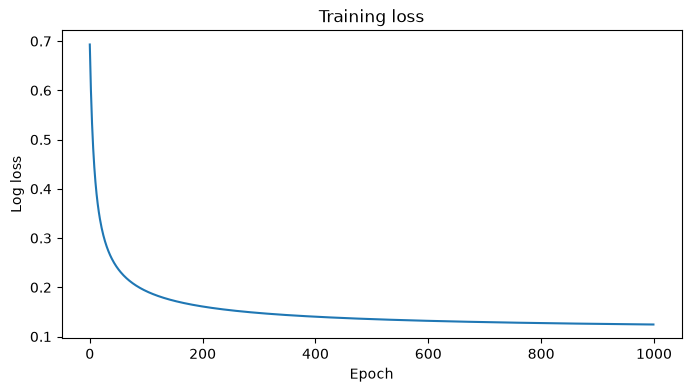

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_loss(y, p):
    eps = 1e-15
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def train_logistic(X, y, lr=0.1, epochs=1000):
    m, n = X.shape
    # Add bias column
    Xb = np.column_stack([np.ones(m), X])
    w = np.zeros(n + 1)
    history = []
    for i in range(epochs):
        z = Xb @ w
        p = sigmoid(z)
        loss = log_loss(y, p)
        grad = (1 / m) * (Xb.T @ (p - y))
        w -= lr * grad
        history.append(loss)
    return w, history

w, history = train_logistic(X, y)
print(f"Learned weights (bias, w1, w2): {w}")
print(f"Final log loss: {history[-1]:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Log loss")
plt.title("Training loss")
plt.show()


## 8. Predict and Evaluate

Compute probabilities and class predictions, then evaluate.


In [3]:
def predict_proba(X, w):
    Xb = np.column_stack([np.ones(len(X)), X])
    return sigmoid(Xb @ w)

p = predict_proba(X, w)
y_pred = (p > 0.5).astype(int)

print(f"Accuracy:  {accuracy_score(y, y_pred):.3f}")
print(f"Precision: {precision_score(y, y_pred):.3f}")
print(f"Recall:    {recall_score(y, y_pred):.3f}")
print(f"F1:        {f1_score(y, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y, p):.3f}")


Accuracy:  0.953
Precision: 0.963
Recall:    0.938
F1:        0.950
ROC-AUC:   0.992


## 9. Compare to scikit-learn

Verify our implementation matches sklearn.


In [4]:
model = LogisticRegression()
model.fit(X, y)
sk_p = model.predict_proba(X)[:, 1]
sk_acc = accuracy_score(y, model.predict(X))
print(f"sklearn accuracy: {sk_acc:.3f}")
print(f"Ours accuracy:    {accuracy_score(y, y_pred):.3f}")
print(f"sklearn ROC-AUC:  {roc_auc_score(y, sk_p):.3f}")
print(f"Ours ROC-AUC:     {roc_auc_score(y, p):.3f}")
print("\nThey match closely!")


sklearn accuracy: 0.950
Ours accuracy:    0.953
sklearn ROC-AUC:  0.992
Ours ROC-AUC:     0.992

They match closely!


## 10. ROC Curve

The ROC curve shows the tradeoff between true positive rate and false positive rate.


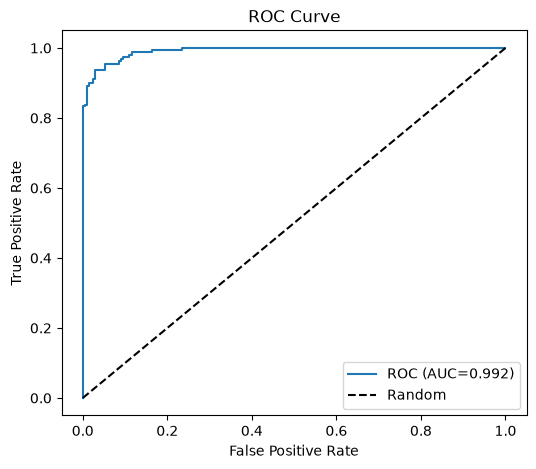

In [5]:
fpr, tpr, _ = roc_curve(y, p)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc_score(y, p):.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## 11. Failure Case: Imbalanced Data

Accuracy is misleading when classes are imbalanced.


In [6]:
# Imbalanced data: 90% class 0
y_imb = np.where(np.random.rand(n) < 0.9, 0, 1)
print(f"Class balance: {y_imb.mean():.2f}")
print(f"Majority-class accuracy: {1 - y_imb.mean():.3f}")
print("\nA model predicting all 0s gets 90% accuracy but is useless.")
print("Use precision/recall/F1 or ROC-AUC for imbalanced data.")


Class balance: 0.11
Majority-class accuracy: 0.892

A model predicting all 0s gets 90% accuracy but is useless.
Use precision/recall/F1 or ROC-AUC for imbalanced data.


## 12. Debugging: Common Errors

- **Log(0)**: clip probabilities to avoid log(0).
- **Learning rate too high**: divergence.
- **Unscaled features**: slow convergence.
- **Imbalanced data**: accuracy is misleading.

## 13. Real-World Considerations

- Use probabilities, not just hard labels, for ranking.
- Set the decision threshold based on the cost of errors.
- Use class weights for imbalanced data.

## 14. Common Mistakes

- Using accuracy on imbalanced data.
- Not scaling features.
- Ignoring the probability output.

## 15. When NOT to Use

- When the decision boundary is highly nonlinear.
- When you need complex interactions.

## 16. Challenge

Implement multiclass logistic regression using softmax and one-vs-rest.


In [7]:
# Challenge: multiclass with softmax (one-vs-rest approach)
from sklearn.datasets import make_classification
from sklearn.preprocessing import label_binarize

X3, y3 = make_classification(n_samples=300, n_features=4, n_informative=3, n_redundant=0, n_classes=3, random_state=42)

# One-vs-rest: train a binary classifier for each class
classes = np.unique(y3)
models = {}
for c in classes:
    y_bin = (y3 == c).astype(int)
    w_c, _ = train_logistic(X3, y_bin, lr=0.1, epochs=500)
    models[c] = w_c

# Predict: class with highest probability
probs = np.column_stack([predict_proba(X3, models[c]) for c in classes])
y_pred3 = classes[np.argmax(probs, axis=1)]
print(f"Multiclass accuracy (one-vs-rest): {accuracy_score(y3, y_pred3):.3f}")

# Compare to sklearn
model3 = LogisticRegression(max_iter=1000).fit(X3, y3)
print(f"sklearn multiclass accuracy: {accuracy_score(y3, model3.predict(X3)):.3f}")


Multiclass accuracy (one-vs-rest): 0.697
sklearn multiclass accuracy: 0.700


## 17. Closed-Book Recall

Without looking back:

1. Write the sigmoid function.
2. Write the log loss.
3. What is ROC-AUC?
4. Why is accuracy misleading on imbalanced data?

## 18. Teach-Back Questions

Explain to another person:

- How logistic regression outputs probabilities.
- The difference between precision and recall.

## 19. Summary

You implemented logistic regression from scratch, evaluated it with multiple metrics, and compared to sklearn. You now understand classification fundamentals.

## 20. Further Experiment

- Add L2 regularization.
- Tune the decision threshold.

## 21. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, matplotlib, scikit-learn
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
